# EE 446 TinyML — Model Pruning with Quantization  
## Student TODO Version: Pruning and Quantization of a DNN Using the UCI Human Activity Recognition Dataset

### Overview
In this notebook, you will:
- train a baseline DNN on the **UCI HAR** dataset,
- apply **magnitude-based pruning**,
- compare the pruned model before and after `strip_pruning(...)`, and
- combine pruning with **float16 quantization**.

Use the **`Python (tinyml-arduino)`** Jupyter kernel for this notebook.


## 1. Environment Setup

This notebook is designed to run with the **`Python (tinyml-arduino)`** Jupyter kernel that you already created.

This notebook assumes the environment already contains:
- `tensorflow==2.14.1`
- `tensorflow-model-optimization==0.8.0`
- `numpy`, `pandas`, `matplotlib`, and `scikit-learn`

Do **not** reinstall TensorFlow packages inside the notebook if you are already using the working TinyML environment.


In [1]:
import os
# TF-MOT (pruning) relies on the Keras 2 API. On TensorFlow 2.16+ tf.keras
# defaults to Keras 3, so we opt in to the legacy Keras backend BEFORE
# importing TensorFlow. This keeps the notebook working on newer TF builds.
os.environ.setdefault("TF_USE_LEGACY_KERAS", "1")

import math
import zipfile
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python executable:", os.sys.executable)
print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)

Python executable: /Users/lukevalerio/miniconda3/bin/python
TensorFlow version: 2.21.0
TF-MOT version: 0.8.1


## 2. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals,
- **6 activity classes**, and
- predefined **training** and **test** splits.

The code below downloads and extracts the dataset if it is not already present in the working directory.


In [2]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    urllib.request.urlretrieve(dataset_url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 3. Load the Data

In [3]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # Load features as float32 and labels as zero-based int32 class indices.
    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt")).astype(np.float32)
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt")).astype(np.int32) - 1
    X_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt")).astype(np.float32)
    y_test = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt")).astype(np.int32) - 1
    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

num_features = X_train.shape[1]
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)
print("Number of features:", num_features)
print("Number of classes :", num_classes)

X_train shape: (7352, 561)
y_train shape: (7352,)
X_test shape : (2947, 561)
y_test shape : (2947,)
Number of features: 561
Number of classes : 6


## 4. Quick Inspection

In [4]:
unique, counts = np.unique(y_train, return_counts=True)
summary = pd.DataFrame({
    "Class Index": unique,
    "Class Name": [class_names[i] for i in unique],
    "Training Samples": counts
})
print(summary.to_string(index=False))

 Class Index         Class Name  Training Samples
           0            WALKING              1226
           1   WALKING_UPSTAIRS              1073
           2 WALKING_DOWNSTAIRS               986
           3            SITTING              1286
           4           STANDING              1374
           5             LAYING              1407


## 5. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [5]:
def build_baseline_model(input_dim, num_classes):
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()

Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 dense (Dense)               (None, 256)               143872    


 dense_1 (Dense)             (None, 128)               32896     


...

 dense_3 (Dense)             (None, 6)                 390       


Total params: 185414 (724.27 KB)


Trainable params: 185414 (724.27 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


### Train the Baseline Model

In [6]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/40


 1/92 [..............................] - ETA: 49s - loss: 1.8071 - accuracy: 0.0938

31/92 [=========>....................] - ETA: 0s - loss: 0.8593 - accuracy: 0.6588 

63/92 [===================>..........] - ETA: 0s - loss: 0.6099 - accuracy: 0.7584

92/92 [==============================] - 1s 3ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245


...

 1/92 [..............................] - ETA: 0s - loss: 0.0254 - accuracy: 0.9844

27/92 [=======>......................] - ETA: 0s - loss: 0.0380 - accuracy: 0.9867

55/92 [================>.............] - ETA: 0s - loss: 0.1171 - accuracy: 0.9662

83/92 [==========================>...] - ETA: 0s - loss: 0.0948 - accuracy: 0.9718

92/92 [==============================] - 0s 2ms/step - loss: 0.0903 - accuracy: 0.9721 - val_loss: 0.1499 - val_accuracy: 0.9531


### Training Curves

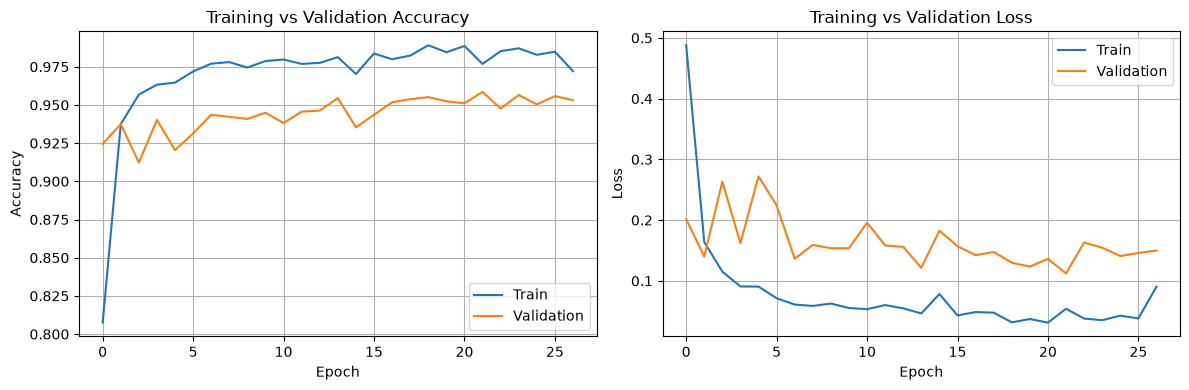

In [7]:
hist = history.history

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist["accuracy"], label="Train")
axes[0].plot(hist["val_accuracy"], label="Validation")
axes[0].set_title("Training vs Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(hist["loss"], label="Train")
axes[1].plot(hist["val_loss"], label="Validation")
axes[1].set_title("Training vs Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 6. Evaluate the Baseline Keras Model

Baseline Keras Test Accuracy: 0.9386

                    precision    recall  f1-score   support

           WALKING     0.9428    0.9637    0.9531       496
  WALKING_UPSTAIRS     0.9533    0.9108    0.9316       471
WALKING_DOWNSTAIRS     0.9236    0.9500    0.9366       420
           SITTING     0.9576    0.8737    0.9137       491
          STANDING     0.8666    0.9643    0.9128       532
            LAYING     1.0000    0.9646    0.9820       537

          accuracy                         0.9386      2947
         macro avg     0.9406    0.9379    0.9383      2947
      weighted avg     0.9409    0.9386    0.9388      2947



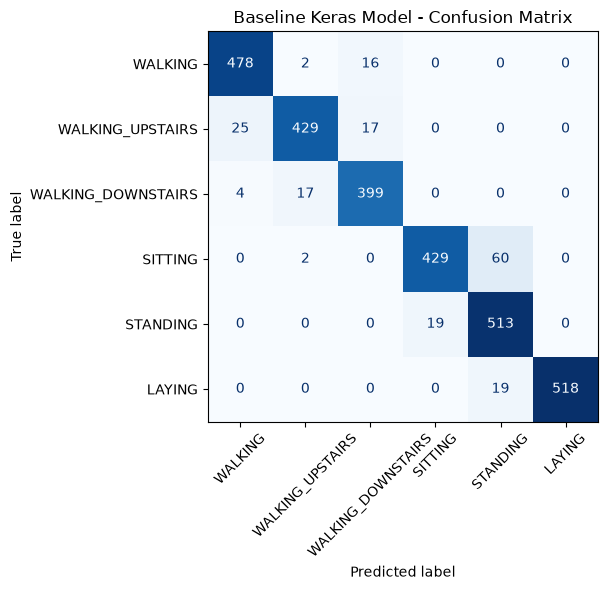

In [8]:
# 1-3. Predict, argmax, accuracy
baseline_probs = baseline_model.predict(X_test, verbose=0)
baseline_preds = np.argmax(baseline_probs, axis=1)
baseline_keras_acc = accuracy_score(y_test, baseline_preds)
print(f"Baseline Keras Test Accuracy: {baseline_keras_acc:.4f}\n")

# 4. Classification report
print(classification_report(y_test, baseline_preds, target_names=class_names, digits=4))

# 5. Confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, baseline_preds),
    display_labels=class_names,
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Baseline Keras Model - Confusion Matrix")
plt.tight_layout()
plt.show()

# Part I: Model Pruning with Sparsity

In this part, we apply **magnitude-based pruning** to the DNN. The key idea is to gradually set small-magnitude weights to zero during training.

We will compare:
1. the baseline TensorFlow Lite model,
2. the pruned model converted **without** stripping the pruning wrappers, and
3. the stripped sparse model converted with **experimental sparsity-aware optimization**.


## 7. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model size.


In [9]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # Quantize the input only when the TFLite input tensor expects int8/uint8;
        # otherwise cast to the required floating-point dtype.
        if input_details["dtype"] in (np.int8, np.uint8):
            x = np.round(x / input_scale + input_zero_point).astype(input_details["dtype"])
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # Dequantize the output only when the output tensor is int8/uint8.
        if output_details["dtype"] in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

## 8. Convert the Baseline Model to TensorFlow Lite

In [10]:
baseline_fp32_tflite = convert_to_tflite_fp32(baseline_model)
baseline_fp32_size = save_binary_model(baseline_fp32_tflite, "pq_baseline_fp32.tflite")
baseline_fp32_acc, baseline_fp32_preds = evaluate_tflite_model(baseline_fp32_tflite, X_test, y_test)

print(f"Baseline FP32 TFLite Test Accuracy: {baseline_fp32_acc:.4f}")
print(f"Baseline FP32 TFLite Size (KB): {baseline_fp32_size:.2f}")

INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmpa01n4sy5/assets


INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmpa01n4sy5/assets


W0000 00:00:1784244965.752518 54517391 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1784244965.752542 54517391 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1784244965.752879 54517391 reader.cc:83] Reading SavedModel from: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmpa01n4sy5
I0000 00:00:1784244965.753864 54517391 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1784244965.753869 54517391 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmpa01n4sy5
I0000 00:00:1784244965.760058 54517391 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1784244965.761077 54517391 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1784244965.803549 54517391 loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmpa01n4sy5
I0000 00:00:1784244965.815311 54

Baseline FP32 TFLite Test Accuracy: 0.9386
Baseline FP32 TFLite Size (KB): 726.74


## 9. Apply Magnitude-Based Pruning

We will prune the DNN using a **polynomial decay schedule**:
- start from low sparsity,
- gradually increase sparsity during training, and
- finish with a highly sparse model.

After training, we will compare:
- the pruned model **with** the pruning wrappers still present, and
- the final sparse model after applying `strip_pruning(...)`.


In [11]:
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

pruning_epochs = 12
batch_size = 64

# steps_per_epoch uses 80% of the training set (validation_split=0.2)
steps_per_epoch = math.ceil((0.8 * len(X_train)) / batch_size)

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs,
    )
}

# Wrap a fresh baseline DNN with pruning wrappers and compile.
pruned_model = prune_low_magnitude(
    build_baseline_model(num_features, num_classes),
    **pruning_params
)

pruned_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

pruning_history = pruned_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks,
    verbose=1,
)

Epoch 1/12


 1/92 [..............................] - ETA: 2:32 - loss: 1.7364 - accuracy: 0.2969

19/92 [=====>........................] - ETA: 0s - loss: 0.9955 - accuracy: 0.5946  

39/92 [===========>..................] - ETA: 0s - loss: 0.7500 - accuracy: 0.6931

63/92 [===================>..........] - ETA: 0s - loss: 0.5890 - accuracy: 0.7599

...

22/92 [======>.......................] - ETA: 0s - loss: 0.0774 - accuracy: 0.9709

46/92 [==============>...............] - ETA: 0s - loss: 0.0702 - accuracy: 0.9762

70/92 [=====================>........] - ETA: 0s - loss: 0.0663 - accuracy: 0.9772

88/92 [===========================>..] - ETA: 0s - loss: 0.0648 - accuracy: 0.9776

92/92 [==============================] - 0s 3ms/step - loss: 0.0641 - accuracy: 0.9777 - val_loss: 0.1124 - val_accuracy: 0.9497


## 10. Convert the Pruned Model Before and After Stripping the Pruning Wrappers

First, we convert the pruned model **with** the pruning wrappers still attached.

Next, we strip the pruning wrappers and convert the resulting sparse model with:
- `tf.lite.Optimize.EXPERIMENTAL_SPARSITY`

This is the proper way to preserve sparsity in the exported TensorFlow Lite model.


In [12]:
# 1-2. Convert the pruned model WITH the pruning wrappers still attached.
pruned_with_mask_tflite = convert_to_tflite_fp32(pruned_model)
pruned_with_mask_size = save_binary_model(pruned_with_mask_tflite, "pruned_with_mask_fp32.tflite")
pruned_with_mask_acc, pruned_with_mask_preds = evaluate_tflite_model(pruned_with_mask_tflite, X_test, y_test)

print(f"Pruned (with mask) FP32 accuracy: {pruned_with_mask_acc:.4f}")
print(f"Pruned (with mask) FP32 size (KB): {pruned_with_mask_size:.2f}\n")

# 3. Strip the pruning wrappers to obtain the final sparse model.
stripped_model = strip_pruning(pruned_model)

# 4. Convert the stripped model with sparsity-aware optimization.
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite = converter.convert()

# 5. Save and evaluate the stripped sparse model.
stripped_sparse_size = save_binary_model(stripped_sparse_tflite, "stripped_sparse_fp32.tflite")
stripped_sparse_acc, stripped_sparse_preds = evaluate_tflite_model(stripped_sparse_tflite, X_test, y_test)

print(f"Stripped sparse FP32 accuracy: {stripped_sparse_acc:.4f}")
print(f"Stripped sparse FP32 size (KB): {stripped_sparse_size:.2f}")

INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmp9h3b3w3h/assets


INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmp9h3b3w3h/assets


W0000 00:00:1784244975.000399 54517391 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1784244975.000412 54517391 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


I0000 00:00:1784244975.000564 54517391 reader.cc:83] Reading SavedModel from: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmp9h3b3w3h
I0000 00:00:1784244975.003641 54517391 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1784244975.003645 54517391 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmp9h3b3w3h
I0000 00:00:1784244975.020451 54517391 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1784244975.083163 54517391 loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmp9h3b3w3h
I0000 00:00:1784244975.105765 54517391 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 105205 microseconds.
/Users/lukevalerio/miniconda3/lib/python3.13/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please

Pruned (with mask) FP32 accuracy: 0.9376
Pruned (with mask) FP32 size (KB): 1454.23



INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmpdo2ad55p/assets


INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmpdo2ad55p/assets


Stripped sparse FP32 accuracy: 0.9376
Stripped sparse FP32 size (KB): 163.02


W0000 00:00:1784244976.142664 54517391 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1784244976.142679 54517391 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1784244976.142825 54517391 reader.cc:83] Reading SavedModel from: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmpdo2ad55p
I0000 00:00:1784244976.143436 54517391 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1784244976.143440 54517391 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmpdo2ad55p
I0000 00:00:1784244976.147395 54517391 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1784244976.165415 54517391 loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmpdo2ad55p
I0000 00:00:1784244976.172123 54517391 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 29309 microseconds.
W0000 00:00:1

## 11. Part I Comparison: Accuracy and Model Size

In [13]:
part1_df = pd.DataFrame(
    [
        ["Baseline", "FP32", baseline_fp32_acc, baseline_fp32_size],
        ["Pruned (with mask)", "FP32", pruned_with_mask_acc, pruned_with_mask_size],
        ["Stripped Sparse", "FP32 + Sparse", stripped_sparse_acc, stripped_sparse_size],
    ],
    columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"],
)
part1_df

,Model,Format,Test Accuracy,Model Size (KB)
0,Baseline,FP32,0.938582,726.738281
1,Pruned (with mask),FP32,0.937564,1454.234375
2,Stripped Sparse,FP32 + Sparse,0.937564,163.023438


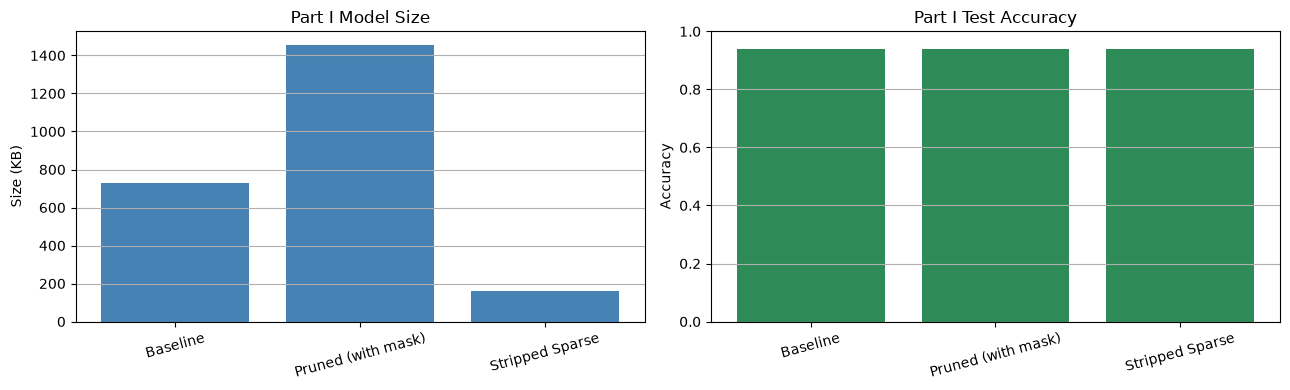

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(part1_df["Model"], part1_df["Model Size (KB)"], color="steelblue")
axes[0].set_title("Part I Model Size")
axes[0].set_ylabel("Size (KB)")
axes[0].tick_params(axis="x", rotation=15)
axes[0].grid(axis="y")

axes[1].bar(part1_df["Model"], part1_df["Test Accuracy"], color="seagreen")
axes[1].set_title("Part I Test Accuracy")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=15)
axes[1].grid(axis="y")

plt.tight_layout()
plt.show()

### Confusion Matrix for the Stripped Sparse Model

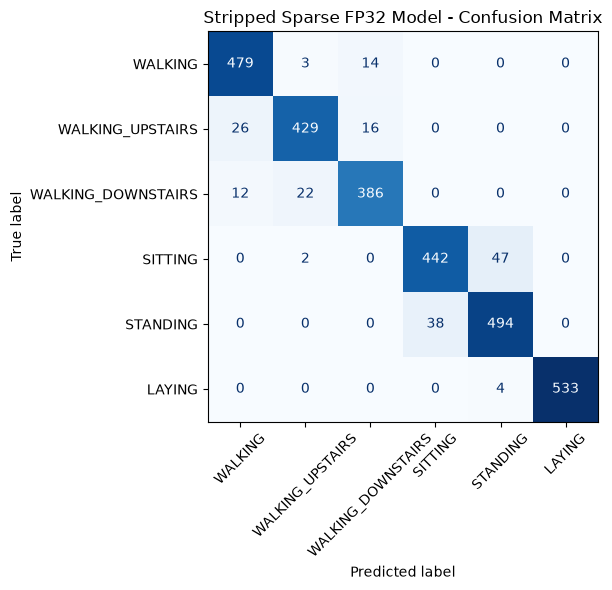

                    precision    recall  f1-score   support

           WALKING     0.9265    0.9657    0.9457       496
  WALKING_UPSTAIRS     0.9408    0.9108    0.9256       471
WALKING_DOWNSTAIRS     0.9279    0.9190    0.9234       420
           SITTING     0.9208    0.9002    0.9104       491
          STANDING     0.9064    0.9286    0.9174       532
            LAYING     1.0000    0.9926    0.9963       537

          accuracy                         0.9376      2947
         macro avg     0.9371    0.9362    0.9365      2947
      weighted avg     0.9378    0.9376    0.9375      2947



In [15]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_preds),
    display_labels=class_names,
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Stripped Sparse FP32 Model - Confusion Matrix")
plt.tight_layout()
plt.show()

print(classification_report(y_test, stripped_sparse_preds, target_names=class_names, digits=4))

# Part II: Model Pruning + Float16 Quantization

In this part, we combine **pruning** and **float16 quantization**.

We will compare:
1. the pruned TensorFlow Lite model **with** the pruning wrappers still attached, after float16 quantization, and
2. the stripped sparse TensorFlow Lite model after **both** sparsity-aware optimization and float16 quantization.

This lets us observe whether properly finalizing the pruned model leads to a more compact deployable representation.


In [16]:
# Part II: combine pruning and float16 quantization.

# 1-2. Pruned model WITH mask -> float16
converter = tf.lite.TFLiteConverter.from_keras_model(pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
pruned_fp16_with_mask_tflite = converter.convert()

pruned_fp16_with_mask_size = save_binary_model(pruned_fp16_with_mask_tflite, "pruned_with_mask_float16.tflite")
pruned_fp16_with_mask_acc, pruned_fp16_with_mask_preds = evaluate_tflite_model(
    pruned_fp16_with_mask_tflite, X_test, y_test
)

print(f"Pruned (with mask) Float16 accuracy: {pruned_fp16_with_mask_acc:.4f}")
print(f"Pruned (with mask) Float16 size (KB): {pruned_fp16_with_mask_size:.2f}\n")

# 3-4. Stripped sparse model -> sparsity-aware + float16
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.target_spec.supported_types = [tf.float16]
stripped_sparse_fp16_tflite = converter.convert()

stripped_sparse_fp16_size = save_binary_model(stripped_sparse_fp16_tflite, "stripped_sparse_float16.tflite")
stripped_sparse_fp16_acc, stripped_sparse_fp16_preds = evaluate_tflite_model(
    stripped_sparse_fp16_tflite, X_test, y_test
)

print(f"Stripped sparse Float16 accuracy: {stripped_sparse_fp16_acc:.4f}")
print(f"Stripped sparse Float16 size (KB): {stripped_sparse_fp16_size:.2f}")

INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmp5jnspgqv/assets


INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmp5jnspgqv/assets


W0000 00:00:1784244979.953322 54517391 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1784244979.953344 54517391 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1784244979.953539 54517391 reader.cc:83] Reading SavedModel from: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmp5jnspgqv
I0000 00:00:1784244979.956662 54517391 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1784244979.956668 54517391 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmp5jnspgqv
I0000 00:00:1784244979.973844 54517391 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1784244980.035019 54517391 loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmp5jnspgqv
I0000 00:00:1784244980.055992 54517391 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 102457 microseconds.
/Users/lukev

Pruned (with mask) Float16 accuracy: 0.9376
Pruned (with mask) Float16 size (KB): 732.71



INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmpn_vuyunu/assets


INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmpn_vuyunu/assets


Stripped sparse Float16 accuracy: 0.9376
Stripped sparse Float16 size (KB): 108.86


W0000 00:00:1784244981.127783 54517391 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1784244981.127803 54517391 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1784244981.127996 54517391 reader.cc:83] Reading SavedModel from: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmpn_vuyunu
I0000 00:00:1784244981.128729 54517391 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1784244981.128734 54517391 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmpn_vuyunu
I0000 00:00:1784244981.133526 54517391 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1784244981.155210 54517391 loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmpn_vuyunu
I0000 00:00:1784244981.163275 54517391 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 35284 microseconds.
W0000 00:00:1

## 12. Part II Comparison: Accuracy and Model Size

In [17]:
part2_df = pd.DataFrame(
    [
        ["Pruned (with mask)", "FP32", pruned_with_mask_acc, pruned_with_mask_size],
        ["Stripped Sparse", "FP32 + Sparse", stripped_sparse_acc, stripped_sparse_size],
        ["Pruned (with mask)", "Float16", pruned_fp16_with_mask_acc, pruned_fp16_with_mask_size],
        ["Stripped Sparse", "Float16 + Sparse", stripped_sparse_fp16_acc, stripped_sparse_fp16_size],
    ],
    columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"],
)
part2_df

,Model,Format,Test Accuracy,Model Size (KB)
0,Pruned (with mask),FP32,0.937564,1454.234375
1,Stripped Sparse,FP32 + Sparse,0.937564,163.023438
2,Pruned (with mask),Float16,0.937564,732.707031
3,Stripped Sparse,Float16 + Sparse,0.937564,108.855469


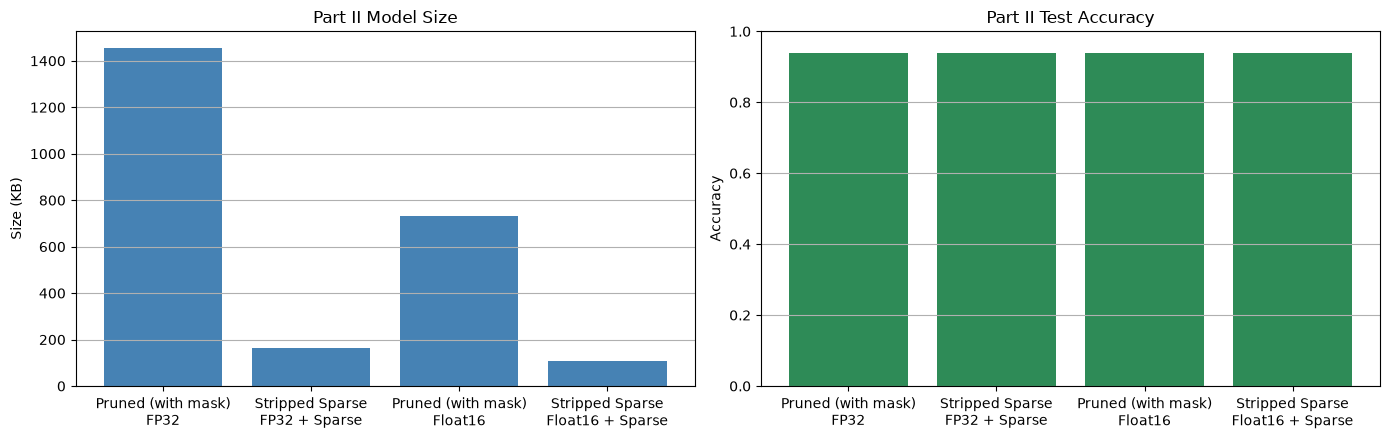

In [18]:
labels = part2_df["Model"] + "\n" + part2_df["Format"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].bar(labels, part2_df["Model Size (KB)"], color="steelblue")
axes[0].set_title("Part II Model Size")
axes[0].set_ylabel("Size (KB)")
axes[0].grid(axis="y")

axes[1].bar(labels, part2_df["Test Accuracy"], color="seagreen")
axes[1].set_title("Part II Test Accuracy")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].grid(axis="y")

plt.tight_layout()
plt.show()

### Confusion Matrix for the Stripped Sparse + Float16 Model

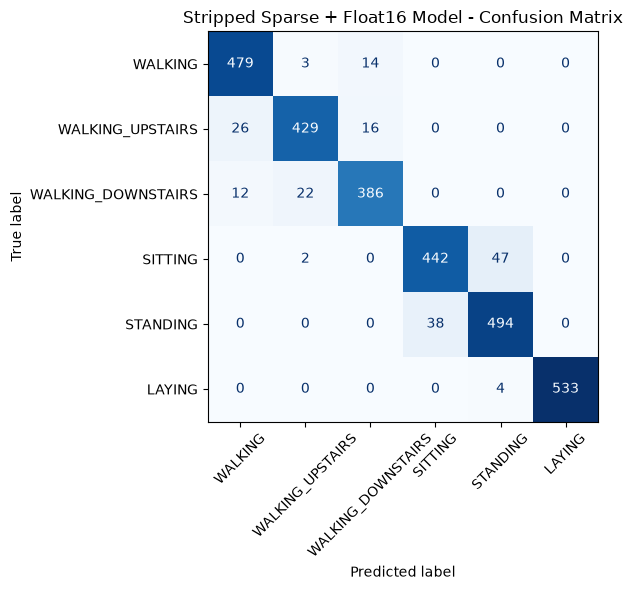

                    precision    recall  f1-score   support

           WALKING     0.9265    0.9657    0.9457       496
  WALKING_UPSTAIRS     0.9408    0.9108    0.9256       471
WALKING_DOWNSTAIRS     0.9279    0.9190    0.9234       420
           SITTING     0.9208    0.9002    0.9104       491
          STANDING     0.9064    0.9286    0.9174       532
            LAYING     1.0000    0.9926    0.9963       537

          accuracy                         0.9376      2947
         macro avg     0.9371    0.9362    0.9365      2947
      weighted avg     0.9378    0.9376    0.9375      2947



In [19]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_fp16_preds),
    display_labels=class_names,
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Stripped Sparse + Float16 Model - Confusion Matrix")
plt.tight_layout()
plt.show()

print(classification_report(y_test, stripped_sparse_fp16_preds, target_names=class_names, digits=4))

## 13. Summary Questions

**1. Did pruning alone reduce the TensorFlow Lite file size when the pruning wrappers were still attached?**

No, it actually made the file larger. The pruning brought its wrappers along with it, and those add an extra mask tensor for every weight tensor just to keep track of which weights are on and off. On top of that, the zeros it created are still stored as full size numbers, so they take up just as much space as the original values did. Between the extra masks and the zeros still sitting there, the pruned file with the wrappers came out to 1454 KB, which is double the 726 KB baseline.

**2. Why does strip_pruning matter before export?**

Strip pruning removes the wrappers and the mask bookkeeping and leaves a plain model with the zeros baked into it. It does not shrink the file by itself, because the zeros are still there right after stripping. What it does is clear the wrappers out of the way so the sparsity aware encoding can run afterward and actually skip storing all the zeros. So stripping is the step that lets the real size savings happen, taking us down to 163 KB.

**3. Which model had the smallest file size in this notebook?**

The smallest model was the stripped sparse float16 model at 108.9 KB. This is because we stacked two things that each cut the size in a different way. The sparsity aware encoding skipped storing the 85% of weights that were zero, and the float16 compression then cut the remaining non zero weights down from 4 bytes to 2.

**4. Did float16 quantization noticeably change the test accuracy?**

No it did not. Every pruned version, whether it was float32 or float16 or stripped sparse, stayed at 0.9376, so the final predictions were basically unchanged. The only step in the whole notebook that cost any accuracy at all was the pruning itself, and even that was tiny, going from 0.9386 down to 0.9376 for zeroing out 85% of the weights.

**5. If you were deploying this model on a resource-constrained device, which version would you choose and why?**

I would choose the stripped sparse float16 model since it had the smallest footprint at 108.9 KB and nearly no accuracy loss. The one thing to keep in mind is that this version needs a device that can handle float16 math and sparse tensors. If I were on a bare integer only board instead, I would go with the int8 route, which is exactly what the next notebook does.

## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- output cells or screenshots showing the comparison tables,
- confusion matrices for the baseline model and your final highlighted compressed model,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors using the **`Python (tinyml-arduino)`** kernel.
